<a href="https://colab.research.google.com/github/Dania-Yasir/flyrak-project/blob/main/work/notebooks/w05_model_training!.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Dania-Yasir/flyrak-project/blob/main/work/notebooks/w05_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# W05 Final Model — Content Decline Ranking

**Lane:** supervised ranking from a binary future-decline proxy  
**Final candidates:** Logistic Regression and Random Forest  
**Official benchmark:** the Week-4 rule baseline  
**Primary metric:** Precision@100  
**Primary validation:** balanced client-disjoint 5-fold validation

This notebook follows the Week-5 skeleton in order:

1. **Method choice and why**
2. **Split design**
3. **Train + compare vs my Week-4 baseline**
4. **Errors and interpretation**
5. **Self-check / robustness**

The operational question is:

> **Using only information available in the first half of a month, can a learned model rank pages that later experience a material impression decline better than my Week-4 rule baseline?**

The Week-4 baseline rule is preserved:

> Prioritize pages already ranking in the **Top 20** whose CTR is **low relative to pages in a similar position bucket**, then rank matched pages by first-half impressions.

The Week-4 notebook reported **39.0% Precision@100** when that rule ranked the full March queue once.  
For Week 5, I recompute the **same rule inside each validation split** so baseline and models are evaluated on exactly the same held-out pages.


In [1]:
%pip install -q duckdb huggingface_hub pandas numpy scikit-learn matplotlib

In [2]:
import calendar
import warnings
from getpass import getpass

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
PRIMARY_K = 100
MACRO_K = 10
DECLINE_THRESHOLD_PCT = -20.0
N_SPLITS = 5
SIMPLICITY_TIE_PP = 1.0

np.random.seed(RANDOM_STATE)

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)


pandas: 2.2.3
numpy: 2.1.3
scikit-learn: 1.6.1


In [3]:
# Public-safe Hugging Face authentication.
# Never hard-code the token in this notebook.

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = None

if not HF_TOKEN:
    HF_TOKEN = getpass("Enter your Hugging Face READ token: ")

if not HF_TOKEN:
    raise ValueError("A Hugging Face READ token is required.")

con = duckdb.connect()
safe_token = HF_TOKEN.replace("'", "''")
con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{safe_token}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

print("Connected successfully.")


Connected successfully.


# 1) Method choice and why

The target is binary:

- `1` = average daily impressions in the outcome window are **more than 20% lower** than in the feature window;
- `0` = otherwise.

But the business use is ranking, not hard classification. I therefore use model probabilities as risk scores and evaluate the first pages a reviewer would inspect.

### Methods

**Week-4 rule baseline**  
The honest benchmark. If ML cannot beat the existing transparent rule on the same held-out data, extra complexity is not justified.

**Logistic Regression**  
A readable linear benchmark. It shows whether the engineered signals work without nonlinear interactions.

**Random Forest**  
A stronger nonlinear model that can capture interactions between traffic level, trend shape, CTR, position, activity, and client-relative context.

I do **not** add Gradient Boosting or tune a large model grid here. The task does not reward complexity alone.

### Why no nested cross-validation?

The model settings below are fixed **before** final validation. There is no hyperparameter search on the evaluation folds.

Nested CV would be important if I were choosing hyperparameters inside cross-validation. With frozen settings, it would add runtime and explanation without solving a problem this experiment currently has.


# 2) Split design

## Temporal information boundary

For March:

- **Features:** March 1–15, 2026
- **Outcome:** March 16–31, 2026

The feature window is divided into three 5-day blocks to capture trend shape.  
The outcome window is used only after features are complete.

## Primary validation: balanced client-disjoint folds

Pages from the same client can share traffic scale and behavior. A row-random split can therefore give an optimistic result.

The primary validation keeps complete clients out of training.

A standard grouped splitter previously produced folds with very different client counts. To avoid one-client test folds, the primary splitter enforces approximately:

> **7 / 7 / 7 / 7 / 6 clients**

It then balances rows and outcome prevalence as much as possible **without using model performance**.

Later, the Self-check section deliberately removes that optimization and tests 10 random balanced client partitions.


In [4]:
# Feature groups are declared once and reused for March and the temporal holdout.

ANCHOR_FEATURES = [
    "imp_momentum_pct",
    "imp_momentum_log",
]

LEVEL_FEATURES = [
    "log_imp_first_half",
    "log_clicks_first_half",
    "ctr_first_half",
    "avg_position_first_half",
    "active_rate_first_half",
]

TREND_SHAPE_FEATURES = [
    "imp_step12_log",
    "imp_step23_log",
    "imp_acceleration",
    "imp_declining_steps",
    "imp_recent_vs_prior_log",
    "click_step23_log",
    "ctr_change_5d_pp",
    "position_change_5d",
    "active_rate_change_5d",
    "has_position_shape",
]

CLIENT_CONTEXT_FEATURES = [
    "log_imp_client_percentile",
    "ctr_client_percentile",
    "position_client_percentile",
    "recent_vs_prior_client_percentile",
]

CONTEXT_FEATURES = (
    LEVEL_FEATURES
    + TREND_SHAPE_FEATURES
    + CLIENT_CONTEXT_FEATURES
)
FULL_FEATURES = ANCHOR_FEATURES + CONTEXT_FEATURES

print("Momentum anchor features:", len(ANCHOR_FEATURES))
print("Context features:", len(CONTEXT_FEATURES))
print("Full features:", len(FULL_FEATURES))


Momentum anchor features: 2
Context features: 19
Full features: 21


In [5]:
def safe_pct_change(new_value, old_value):
    denom = np.maximum(np.asarray(old_value, dtype=float), 1.0)
    return (
        (
            np.asarray(new_value, dtype=float)
            - np.asarray(old_value, dtype=float)
        )
        / denom
    ) * 100.0


def build_month_model_frame(month_str):
    """
    Build one month's feature population and outcome-evaluable cohort.

    Feature window: days 1-15.
    Outcome window: days 16-end of month.

    Client-relative ranks are computed on the pre-outcome feature population,
    before filtering on future coverage.
    """
    year, month = map(int, month_str.split("-"))
    last_day = calendar.monthrange(year, month)[1]
    future_days = last_day - 15

    d1 = f"{month_str}-01"
    d5 = f"{month_str}-05"
    d6 = f"{month_str}-06"
    d7 = f"{month_str}-07"
    d8 = f"{month_str}-08"
    d10 = f"{month_str}-10"
    d11 = f"{month_str}-11"
    d15 = f"{month_str}-15"
    d16 = f"{month_str}-16"
    dend = f"{month_str}-{last_day:02d}"

    fact = (
        f"read_parquet("
        f"'{REL}/fact_content_daily_performance/month={month_str}/*.parquet'"
        f")"
    )

    query = f"""
    SELECT
        client_hash_id AS client_id,
        content_hash_id AS content_id,

        SUM(CASE WHEN report_date BETWEEN DATE '{d1}' AND DATE '{d5}'
                 THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_w1,
        SUM(CASE WHEN report_date BETWEEN DATE '{d1}' AND DATE '{d5}'
                 THEN COALESCE(gsc_clicks, 0) ELSE 0 END) AS clicks_w1,
        SUM(CASE WHEN report_date BETWEEN DATE '{d1}' AND DATE '{d5}'
                 THEN COALESCE(gsc_sum_position, 0) ELSE 0 END) AS sum_position_w1,
        SUM(CASE WHEN report_date BETWEEN DATE '{d1}' AND DATE '{d5}'
                      AND COALESCE(gsc_impressions, 0) > 0
                 THEN 1 ELSE 0 END) AS active_days_w1,

        SUM(CASE WHEN report_date BETWEEN DATE '{d6}' AND DATE '{d10}'
                 THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_w2,
        SUM(CASE WHEN report_date BETWEEN DATE '{d6}' AND DATE '{d10}'
                 THEN COALESCE(gsc_clicks, 0) ELSE 0 END) AS clicks_w2,
        SUM(CASE WHEN report_date BETWEEN DATE '{d6}' AND DATE '{d10}'
                 THEN COALESCE(gsc_sum_position, 0) ELSE 0 END) AS sum_position_w2,
        SUM(CASE WHEN report_date BETWEEN DATE '{d6}' AND DATE '{d10}'
                      AND COALESCE(gsc_impressions, 0) > 0
                 THEN 1 ELSE 0 END) AS active_days_w2,

        SUM(CASE WHEN report_date BETWEEN DATE '{d11}' AND DATE '{d15}'
                 THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_w3,
        SUM(CASE WHEN report_date BETWEEN DATE '{d11}' AND DATE '{d15}'
                 THEN COALESCE(gsc_clicks, 0) ELSE 0 END) AS clicks_w3,
        SUM(CASE WHEN report_date BETWEEN DATE '{d11}' AND DATE '{d15}'
                 THEN COALESCE(gsc_sum_position, 0) ELSE 0 END) AS sum_position_w3,
        SUM(CASE WHEN report_date BETWEEN DATE '{d11}' AND DATE '{d15}'
                      AND COALESCE(gsc_impressions, 0) > 0
                 THEN 1 ELSE 0 END) AS active_days_w3,

        SUM(CASE WHEN report_date BETWEEN DATE '{d1}' AND DATE '{d7}'
                 THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_early7,
        SUM(CASE WHEN report_date BETWEEN DATE '{d8}' AND DATE '{d15}'
                 THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_late8,

        SUM(CASE WHEN report_date BETWEEN DATE '{d1}' AND DATE '{d15}'
                      AND COALESCE(gsc_data_available, FALSE)
                 THEN 1 ELSE 0 END) AS gsc_days_features,

        SUM(CASE WHEN report_date BETWEEN DATE '{d16}' AND DATE '{dend}'
                      AND COALESCE(gsc_data_available, FALSE)
                 THEN 1 ELSE 0 END) AS gsc_days_future,

        SUM(CASE WHEN report_date BETWEEN DATE '{d16}' AND DATE '{dend}'
                 THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_future

    FROM {fact}
    WHERE report_date BETWEEN DATE '{d1}' AND DATE '{dend}'
    GROUP BY client_hash_id, content_hash_id
    """

    raw = con.execute(query).df()

    feature_pop = raw[
        raw["gsc_days_features"] == 15
    ].copy()

    feature_pop["imp_first_half"] = (
        feature_pop["imp_w1"]
        + feature_pop["imp_w2"]
        + feature_pop["imp_w3"]
    )
    feature_pop["clicks_first_half"] = (
        feature_pop["clicks_w1"]
        + feature_pop["clicks_w2"]
        + feature_pop["clicks_w3"]
    )
    feature_pop["sum_position_first_half"] = (
        feature_pop["sum_position_w1"]
        + feature_pop["sum_position_w2"]
        + feature_pop["sum_position_w3"]
    )
    feature_pop["active_days_first_half"] = (
        feature_pop["active_days_w1"]
        + feature_pop["active_days_w2"]
        + feature_pop["active_days_w3"]
    )

    feature_pop = feature_pop[
        feature_pop["imp_first_half"] > 0
    ].copy()

    feature_pop["avg_position_first_half"] = (
        feature_pop["sum_position_first_half"]
        / feature_pop["imp_first_half"]
    )
    feature_pop = feature_pop[
        feature_pop["avg_position_first_half"].notna()
        & (feature_pop["avg_position_first_half"] > 0)
    ].copy()

    # Stable level features.
    feature_pop["log_imp_first_half"] = np.log1p(
        feature_pop["imp_first_half"]
    )
    feature_pop["log_clicks_first_half"] = np.log1p(
        feature_pop["clicks_first_half"]
    )
    feature_pop["ctr_first_half"] = (
        feature_pop["clicks_first_half"]
        / feature_pop["imp_first_half"]
    ) * 100.0
    feature_pop["active_rate_first_half"] = (
        feature_pop["active_days_first_half"] / 15.0
    )

    # Momentum anchor.
    feature_pop["avg_daily_imp_early7"] = (
        feature_pop["imp_early7"] / 7.0
    )
    feature_pop["avg_daily_imp_late8"] = (
        feature_pop["imp_late8"] / 8.0
    )
    feature_pop["imp_momentum_pct"] = safe_pct_change(
        feature_pop["avg_daily_imp_late8"],
        feature_pop["avg_daily_imp_early7"],
    )
    feature_pop["imp_momentum_log"] = (
        np.log1p(feature_pop["avg_daily_imp_late8"])
        - np.log1p(feature_pop["avg_daily_imp_early7"])
    )

    # Three equal 5-day blocks.
    for w in (1, 2, 3):
        feature_pop[f"avg_daily_imp_w{w}"] = (
            feature_pop[f"imp_w{w}"] / 5.0
        )
        feature_pop[f"avg_daily_clicks_w{w}"] = (
            feature_pop[f"clicks_w{w}"] / 5.0
        )
        feature_pop[f"ctr_w{w}"] = np.where(
            feature_pop[f"imp_w{w}"] > 0,
            (
                feature_pop[f"clicks_w{w}"]
                / feature_pop[f"imp_w{w}"]
            ) * 100.0,
            0.0,
        )
        feature_pop[f"avg_position_w{w}"] = np.where(
            feature_pop[f"imp_w{w}"] > 0,
            (
                feature_pop[f"sum_position_w{w}"]
                / feature_pop[f"imp_w{w}"]
            ),
            np.nan,
        )
        feature_pop[f"active_rate_w{w}"] = (
            feature_pop[f"active_days_w{w}"] / 5.0
        )

    feature_pop["imp_step12_log"] = (
        np.log1p(feature_pop["avg_daily_imp_w2"])
        - np.log1p(feature_pop["avg_daily_imp_w1"])
    )
    feature_pop["imp_step23_log"] = (
        np.log1p(feature_pop["avg_daily_imp_w3"])
        - np.log1p(feature_pop["avg_daily_imp_w2"])
    )
    feature_pop["imp_acceleration"] = (
        feature_pop["imp_step23_log"]
        - feature_pop["imp_step12_log"]
    )
    feature_pop["imp_declining_steps"] = (
        (
            feature_pop["avg_daily_imp_w2"]
            < feature_pop["avg_daily_imp_w1"]
        ).astype(int)
        + (
            feature_pop["avg_daily_imp_w3"]
            < feature_pop["avg_daily_imp_w2"]
        ).astype(int)
    )
    feature_pop["imp_recent_vs_prior_log"] = (
        np.log1p(feature_pop["avg_daily_imp_w3"])
        - np.log1p(
            (
                feature_pop["avg_daily_imp_w1"]
                + feature_pop["avg_daily_imp_w2"]
            ) / 2.0
        )
    )
    feature_pop["click_step23_log"] = (
        np.log1p(feature_pop["avg_daily_clicks_w3"])
        - np.log1p(feature_pop["avg_daily_clicks_w2"])
    )
    feature_pop["ctr_change_5d_pp"] = (
        feature_pop["ctr_w3"]
        - feature_pop["ctr_w1"]
    )
    feature_pop["position_change_5d"] = (
        feature_pop["avg_position_w3"]
        - feature_pop["avg_position_w1"]
    ).fillna(0.0)
    feature_pop["has_position_shape"] = (
        feature_pop["avg_position_w1"].notna()
        & feature_pop["avg_position_w3"].notna()
    ).astype(int)
    feature_pop["active_rate_change_5d"] = (
        feature_pop["active_rate_w3"]
        - feature_pop["active_rate_w1"]
    )

    # Client-relative context uses PRE-OUTCOME data only.
    groups = feature_pop.groupby("client_id")
    feature_pop["log_imp_client_percentile"] = (
        groups["log_imp_first_half"].rank(pct=True)
    )
    feature_pop["ctr_client_percentile"] = (
        groups["ctr_first_half"].rank(pct=True)
    )
    feature_pop["position_client_percentile"] = (
        groups["avg_position_first_half"].rank(pct=True)
    )
    feature_pop["recent_vs_prior_client_percentile"] = (
        groups["imp_recent_vs_prior_log"].rank(pct=True)
    )

    model = feature_pop[
        feature_pop["gsc_days_future"] == future_days
    ].copy().reset_index(drop=True)

    model["avg_daily_imp_first_half"] = (
        model["imp_first_half"] / 15.0
    )
    model["avg_daily_imp_future"] = (
        model["imp_future"] / float(future_days)
    )
    model["impression_change_pct"] = (
        (
            model["avg_daily_imp_future"]
            - model["avg_daily_imp_first_half"]
        )
        / model["avg_daily_imp_first_half"]
    ) * 100.0
    model["is_declining_proxy"] = (
        model["impression_change_pct"]
        < DECLINE_THRESHOLD_PCT
    ).astype(int)

    info = {
        "month": month_str,
        "last_day": last_day,
        "future_days": future_days,
        "raw_rows": len(raw),
        "feature_rows": len(feature_pop),
        "model_rows": len(model),
        "clients": model["client_id"].nunique(),
    }

    return raw, feature_pop, model, info


In [6]:
raw_df, feature_population, model_df, march_info = (
    build_month_model_frame("2026-03")
)

target_col = "is_declining_proxy"

print("March data:")
print(march_info)
print("Decline rate:", f"{model_df[target_col].mean():.1%}")
print("Missing model-feature values:", int(
    model_df[FULL_FEATURES].isna().sum().sum()
))

display(
    pd.DataFrame([
        {
            "stage": "Raw monthly rows",
            "rows": len(raw_df),
            "clients": raw_df["client_id"].nunique(),
        },
        {
            "stage": "Feature-eligible before future filtering",
            "rows": len(feature_population),
            "clients": feature_population["client_id"].nunique(),
        },
        {
            "stage": "Outcome-evaluable cohort",
            "rows": len(model_df),
            "clients": model_df["client_id"].nunique(),
        },
    ])
)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

March data:
{'month': '2026-03', 'last_day': 31, 'future_days': 16, 'raw_rows': 331437, 'feature_rows': 68288, 'model_rows': 61795, 'clients': 34}
Decline rate: 32.4%
Missing model-feature values: 0


,stage,rows,clients
0,Raw monthly rows,331437,55
1,Feature-eligible before future filtering,68288,35
2,Outcome-evaluable cohort,61795,34


### Leakage check

The model may use only information available by day 15.

- `client_id` and `content_id` are grouping / joining identifiers only.
- `imp_future`, the target, and future-derived change fields cannot be features.
- Client-relative ranks are computed before future filtering and use only the feature window.


In [7]:
forbidden_exact = {
    target_col,
    "imp_future",
    "avg_daily_imp_future",
    "impression_change_pct",
    "client_id",
    "content_id",
}

forbidden_overlap = sorted(
    set(FULL_FEATURES).intersection(forbidden_exact)
)
future_named_features = sorted([
    c for c in FULL_FEATURES
    if any(
        token in c.lower()
        for token in ["future", "outcome", "target"]
    )
])

print("Forbidden overlap:", forbidden_overlap)
print("Suspicious future-named features:", future_named_features)

assert not forbidden_overlap
assert not future_named_features
assert model_df[FULL_FEATURES].isna().sum().sum() == 0

print("Leakage guard passed.")


Forbidden overlap: []
Suspicious future-named features: []
Leakage guard passed.


In [8]:
def precision_at_k(y_true, scores, k=PRIMARY_K, random_state=RANDOM_STATE):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores, dtype=float)
    k = min(k, len(y_true))

    if k == 0:
        return np.nan

    rng = np.random.default_rng(random_state)
    tie_breaker = rng.random(len(scores))
    order = np.lexsort((tie_breaker, -scores))

    return float(y_true[order[:k]].mean())


def safe_average_precision(y_true, scores):
    y_true = np.asarray(y_true)
    if y_true.sum() == 0:
        return np.nan
    return float(average_precision_score(y_true, scores))


def safe_roc_auc(y_true, scores):
    y_true = np.asarray(y_true)
    if np.unique(y_true).size < 2:
        return np.nan
    return float(roc_auc_score(y_true, scores))


def evaluate_ranking(name, y_true, scores):
    y_true = np.asarray(y_true)
    return {
        "approach": name,
        "base_rate": float(y_true.mean()),
        "p_at_10": precision_at_k(y_true, scores, 10),
        "p_at_100": precision_at_k(y_true, scores, PRIMARY_K),
        "average_precision": safe_average_precision(y_true, scores),
        "roc_auc": safe_roc_auc(y_true, scores),
    }


POSITION_BINS = [0, 3, 10, 20, 50, np.inf]
POSITION_LABELS = ["Top 3", "4-10", "11-20", "21-50", "50+"]


def _position_bucket(frame):
    return pd.cut(
        frame["avg_position_first_half"],
        bins=POSITION_BINS,
        labels=POSITION_LABELS,
        include_lowest=True,
    ).astype("object")


def fit_week4_baseline(reference_frame):
    """
    Fit only the Week-4 rule's position-bucket CTR medians.

    No target is used.
    """
    tmp = reference_frame[
        ["avg_position_first_half", "ctr_first_half"]
    ].copy()
    tmp["position_bucket"] = _position_bucket(tmp)

    medians = (
        tmp.groupby("position_bucket", observed=True)["ctr_first_half"]
        .median()
        .to_dict()
    )

    return {
        "bucket_medians": medians,
        "global_ctr_median": float(tmp["ctr_first_half"].median()),
    }


def score_week4_baseline(reference_frame, score_frame):
    """
    Preserve the Week-4 baseline logic:

    1) Top-20 position
    2) CTR lower than the training/reference median for a similar position bucket
    3) Matched pages ranked by first-half impressions
    """
    fitted = fit_week4_baseline(reference_frame)

    bucket = _position_bucket(score_frame)
    threshold = (
        pd.Series(bucket, index=score_frame.index)
        .map(fitted["bucket_medians"])
        .astype(float)
        .fillna(fitted["global_ctr_median"])
    )

    ctr = score_frame["ctr_first_half"].astype(float)

    low_ctr = np.where(
        threshold > 0,
        ctr < threshold,
        ctr == 0,
    )

    good_position = (
        score_frame["avg_position_first_half"] <= 20
    )

    rule_match = good_position & low_ctr

    return np.where(
        rule_match,
        score_frame["imp_first_half"].astype(float),
        0.0,
    )


def client_precision_rows(frame, scores, approach_name, k=MACRO_K):
    tmp = frame[["client_id", target_col]].copy()
    tmp["_score"] = np.asarray(scores, dtype=float)
    rows = []

    for client_id, group in tmp.groupby("client_id", sort=False):
        if len(group) < k:
            continue

        rows.append({
            "client_id": client_id,
            "approach": approach_name,
            "client_pages": len(group),
            "client_p_at_10": precision_at_k(
                group[target_col],
                group["_score"],
                k=k,
            ),
            "client_base_rate": float(group[target_col].mean()),
        })

    return rows


In [9]:
def make_balanced_client_splits(
    frame,
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE,
    n_restarts=500,
):
    """
    Client-disjoint K-fold splitter with an explicit client-count constraint.

    Guarantees:
    - each client appears in exactly one test fold;
    - fold client counts differ by at most one.

    Optimization target:
    - balance total rows;
    - balance positive rows;
    - balance decline base rate.

    Model performance is NEVER used when choosing the assignment.
    """
    stats = (
        frame.groupby("client_id")[target_col]
        .agg(rows="size", positives="sum")
        .reset_index()
    )
    stats["base_rate"] = (
        stats["positives"] / stats["rows"]
    )

    n_clients = len(stats)
    n_splits = min(int(n_splits), int(n_clients))

    if n_splits < 2:
        raise ValueError("At least two clients are required.")

    # Exact fold capacities.
    # Example: 34 clients, 5 folds -> [7, 7, 7, 7, 6].
    base = n_clients // n_splits
    remainder = n_clients % n_splits

    default_capacities = np.array(
        [
            base + (1 if i < remainder else 0)
            for i in range(n_splits)
        ],
        dtype=int,
    )

    total_rows = float(stats["rows"].sum())
    total_pos = float(stats["positives"].sum())
    global_rate = total_pos / total_rows

    target_rows = total_rows / n_splits
    target_pos = total_pos / n_splits

    rng_master = np.random.default_rng(random_state)
    best = None

    def final_cost(fold_rows, fold_pos):
        fold_rows = np.asarray(fold_rows, dtype=float)
        fold_pos = np.asarray(fold_pos, dtype=float)

        fold_rates = np.divide(
            fold_pos,
            fold_rows,
            out=np.zeros_like(fold_pos),
            where=fold_rows > 0,
        )

        row_imbalance = np.mean(
            ((fold_rows - target_rows) / max(target_rows, 1.0)) ** 2
        )
        pos_imbalance = np.mean(
            ((fold_pos - target_pos) / max(target_pos, 1.0)) ** 2
        )
        rate_imbalance = np.mean(
            (fold_rates - global_rate) ** 2
        )

        # Rows and positives matter most; rate balance is an additional guard.
        return (
            1.0 * row_imbalance
            + 1.25 * pos_imbalance
            + 3.0 * rate_imbalance
        )

    for restart in range(int(n_restarts)):
        rng = np.random.default_rng(
            int(rng_master.integers(0, 2**31 - 1))
        )

        # Randomly decide which folds receive the extra client(s),
        # so no fold number gets privileged.
        capacities = np.full(
            n_splits,
            base,
            dtype=int,
        )
        extra_order = rng.permutation(n_splits)
        capacities[extra_order[:remainder]] += 1

        work = stats.copy()

        # Place difficult-to-balance clients early:
        # large clients + clients with unusual base rate.
        work["_priority"] = (
            np.log1p(work["rows"])
            + 3.0 * np.abs(
                work["base_rate"] - global_rate
            )
            + rng.normal(
                0.0,
                0.05,
                size=len(work),
            )
        )
        work = (
            work.sort_values(
                "_priority",
                ascending=False,
            )
            .reset_index(drop=True)
        )

        fold_clients = [
            [] for _ in range(n_splits)
        ]
        fold_rows = np.zeros(
            n_splits,
            dtype=float,
        )
        fold_pos = np.zeros(
            n_splits,
            dtype=float,
        )

        for row in work.itertuples(index=False):
            eligible = [
                fold
                for fold in range(n_splits)
                if len(fold_clients[fold]) < capacities[fold]
            ]

            candidate_choices = []

            for fold in eligible:
                test_rows = fold_rows.copy()
                test_pos = fold_pos.copy()

                test_rows[fold] += float(row.rows)
                test_pos[fold] += float(row.positives)

                # Partial-state cost. Empty folds are intentionally penalized
                # through the row/positive imbalance terms.
                cost = final_cost(
                    test_rows,
                    test_pos,
                )

                candidate_choices.append(
                    (
                        cost,
                        rng.random(),
                        fold,
                    )
                )

            _, _, chosen_fold = min(
                candidate_choices
            )

            fold_clients[chosen_fold].append(
                row.client_id
            )
            fold_rows[chosen_fold] += float(
                row.rows
            )
            fold_pos[chosen_fold] += float(
                row.positives
            )

        score = final_cost(
            fold_rows,
            fold_pos,
        )

        if (
            best is None
            or score < best["score"]
        ):
            best = {
                "score": score,
                "fold_clients": [
                    list(x)
                    for x in fold_clients
                ],
                "fold_rows": fold_rows.copy(),
                "fold_pos": fold_pos.copy(),
            }

    splits = []

    for clients_in_fold in best["fold_clients"]:
        test_mask = frame["client_id"].isin(
            set(clients_in_fold)
        ).to_numpy()

        test_idx = np.flatnonzero(
            test_mask
        )
        train_idx = np.flatnonzero(
            ~test_mask
        )

        splits.append(
            (train_idx, test_idx)
        )

    # Verification.
    client_counts = [
        frame.iloc[test_idx]["client_id"].nunique()
        for _, test_idx in splits
    ]

    assert max(client_counts) - min(client_counts) <= 1

    all_test_clients = []
    for _, test_idx in splits:
        all_test_clients.extend(
            frame.iloc[test_idx][
                "client_id"
            ].drop_duplicates().tolist()
        )

    assert (
        len(all_test_clients)
        == len(set(all_test_clients))
        == frame["client_id"].nunique()
    )

    return splits, "BalancedClientKFold"

In [10]:
grouped_splits, grouped_strategy = make_balanced_client_splits(
    model_df,
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE,
    n_restarts=500,
)

fold_audit_rows = []

for fold, (_, test_idx) in enumerate(grouped_splits, start=1):
    test_part = model_df.iloc[test_idx]

    fold_audit_rows.append({
        "fold": fold,
        "clients": test_part["client_id"].nunique(),
        "rows": len(test_part),
        "positives": int(test_part[target_col].sum()),
        "base_rate": float(test_part[target_col].mean()),
    })

fold_audit = pd.DataFrame(fold_audit_rows)

print("Primary grouped strategy:", grouped_strategy)
display(
    fold_audit.style.format({
        "base_rate": "{:.1%}",
    })
)

assert (
    fold_audit["clients"].max()
    - fold_audit["clients"].min()
    <= 1
)

print(
    "Client-count range:",
    f"{fold_audit['clients'].min()}–{fold_audit['clients'].max()}",
)
print("Client-disjoint balanced split check passed.")


Primary grouped strategy: BalancedClientKFold


,fold,clients,rows,positives,base_rate
0,1,7,10806,2633,24.4%
1,2,7,11014,2714,24.6%
2,3,7,10493,4377,41.7%
3,4,6,16660,5545,33.3%
4,5,7,12822,4754,37.1%


Client-count range: 6–7
Client-disjoint balanced split check passed.


### Fixed model settings

The settings are frozen before validation.

No tuning is performed on the held-out folds.


In [11]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        C=0.3,
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE,
    )),
])

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=25,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("Models ready.")


Models ready.


# 3) Train + compare vs my Week-4 baseline

This is the **non-negotiable comparison**.

For every fold:

1. hold out complete clients;
2. fit the Week-4 CTR thresholds using training clients only;
3. train Logistic Regression and Random Forest using the same training clients;
4. evaluate all approaches on the **same held-out pages**;
5. use the **same Precision@100 metric**.

I also train a Random Forest using only the two Momentum-anchor features.  
That is an ablation check: does the larger feature set add value beyond simple recent momentum?


In [12]:
primary_rows = []
client_rows = []
oof_frames = []
rf_importance_rows = []

for fold, (train_idx, test_idx) in enumerate(grouped_splits, start=1):
    train_part = model_df.iloc[train_idx].copy()
    test_part = model_df.iloc[test_idx].copy()

    assert set(train_part["client_id"]).isdisjoint(
        set(test_part["client_id"])
    )

    # Official Week-4 rule, fitted only on training/reference features.
    week4_scores = score_week4_baseline(
        train_part,
        test_part,
    )

    # Logistic Regression — full signal.
    lr = clone(logistic_model)
    lr.fit(
        train_part[FULL_FEATURES],
        train_part[target_col],
    )
    lr_scores = lr.predict_proba(
        test_part[FULL_FEATURES]
    )[:, 1]

    # Random Forest — momentum-only ablation.
    rf_momentum = clone(random_forest_model)
    rf_momentum.fit(
        train_part[ANCHOR_FEATURES],
        train_part[target_col],
    )
    rf_momentum_scores = rf_momentum.predict_proba(
        test_part[ANCHOR_FEATURES]
    )[:, 1]

    # Random Forest — full signal.
    rf = clone(random_forest_model)
    rf.fit(
        train_part[FULL_FEATURES],
        train_part[target_col],
    )
    rf_scores = rf.predict_proba(
        test_part[FULL_FEATURES]
    )[:, 1]

    score_map = {
        "Week-4 Rule Baseline": week4_scores,
        "Logistic Regression": lr_scores,
        "Random Forest — Momentum Only": rf_momentum_scores,
        "Random Forest — Full Signal": rf_scores,
    }

    for name, scores in score_map.items():
        metrics = evaluate_ranking(
            name,
            test_part[target_col],
            scores,
        )

        primary_rows.append({
            "fold": fold,
            "test_clients": test_part["client_id"].nunique(),
            "test_rows": len(test_part),
            **metrics,
        })

        client_rows.extend(
            client_precision_rows(
                test_part,
                scores,
                name,
                k=MACRO_K,
            )
        )

    # Safe out-of-fold error table — no IDs.
    fold_oof = test_part[[
        target_col,
        "log_imp_first_half",
        "imp_momentum_pct",
        "imp_acceleration",
        "imp_declining_steps",
        "ctr_change_5d_pp",
        "position_change_5d",
        "active_rate_change_5d",
    ]].copy()

    fold_oof["fold"] = fold
    fold_oof["rf_score"] = rf_scores
    fold_oof["week4_score"] = week4_scores
    oof_frames.append(fold_oof)

    for feature, importance in zip(
        FULL_FEATURES,
        rf.feature_importances_,
    ):
        rf_importance_rows.append({
            "fold": fold,
            "feature": feature,
            "importance": float(importance),
        })

    print(
        f"Fold {fold}/{N_SPLITS} | "
        f"clients={test_part['client_id'].nunique()} | "
        f"W4={precision_at_k(test_part[target_col], week4_scores):.1%} | "
        f"LR={precision_at_k(test_part[target_col], lr_scores):.1%} | "
        f"RF={precision_at_k(test_part[target_col], rf_scores):.1%}"
    )

primary_results = pd.DataFrame(primary_rows)
client_metrics = pd.DataFrame(client_rows)
oof_df = pd.concat(oof_frames, ignore_index=True)
rf_importance_df = pd.DataFrame(rf_importance_rows)

print("Primary grouped validation complete.")


Fold 1/5 | clients=7 | W4=29.0% | LR=40.0% | RF=57.0%
Fold 2/5 | clients=7 | W4=33.0% | LR=64.0% | RF=80.0%
Fold 3/5 | clients=7 | W4=35.0% | LR=61.0% | RF=68.0%
Fold 4/5 | clients=6 | W4=33.0% | LR=90.0% | RF=86.0%
Fold 5/5 | clients=7 | W4=46.0% | LR=93.0% | RF=93.0%
Primary grouped validation complete.


In [13]:
primary_summary = (
    primary_results
    .groupby("approach", as_index=False)
    .agg(
        folds=("fold", "nunique"),
        mean_base_rate=("base_rate", "mean"),
        mean_p100=("p_at_100", "mean"),
        std_p100=("p_at_100", "std"),
        min_p100=("p_at_100", "min"),
        max_p100=("p_at_100", "max"),
        mean_ap=("average_precision", "mean"),
        mean_roc_auc=("roc_auc", "mean"),
    )
    .sort_values(
        ["mean_p100", "mean_ap"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

print("PRIMARY — same clients, same split, same metric:")
display(
    primary_summary.style.format({
        "mean_base_rate": "{:.1%}",
        "mean_p100": "{:.1%}",
        "std_p100": "{:.1%}",
        "min_p100": "{:.1%}",
        "max_p100": "{:.1%}",
        "mean_ap": "{:.3f}",
        "mean_roc_auc": "{:.3f}",
    })
)

fold_p100 = primary_results.pivot(
    index="fold",
    columns="approach",
    values="p_at_100",
)

print("Fold-by-fold Precision@100:")
display(fold_p100.style.format("{:.1%}"))


PRIMARY — same clients, same split, same metric:


,approach,folds,mean_base_rate,mean_p100,std_p100,min_p100,max_p100,mean_ap,mean_roc_auc
0,Random Forest — Full Signal,5,32.2%,76.8%,14.4%,57.0%,93.0%,0.527,0.705
1,Logistic Regression,5,32.2%,69.6%,22.1%,40.0%,93.0%,0.504,0.685
2,Random Forest — Momentum Only,5,32.2%,66.8%,11.5%,54.0%,82.0%,0.451,0.622
3,Week-4 Rule Baseline,5,32.2%,35.2%,6.4%,29.0%,46.0%,0.356,0.543


Fold-by-fold Precision@100:


approach,Logistic Regression,Random Forest — Full Signal,Random Forest — Momentum Only,Week-4 Rule Baseline
fold,,,,
1,40.0%,57.0%,54.0%,29.0%
2,64.0%,80.0%,66.0%,33.0%
3,61.0%,68.0%,58.0%,35.0%
4,90.0%,86.0%,82.0%,33.0%
5,93.0%,93.0%,74.0%,46.0%


In [14]:
# Paired comparison against the official Week-4 baseline.

baseline_fold = fold_p100["Week-4 Rule Baseline"]

paired_rows = []

for name in [
    "Logistic Regression",
    "Random Forest — Full Signal",
]:
    delta = (
        fold_p100[name]
        - baseline_fold
    ) * 100.0

    paired_rows.append({
        "approach": name,
        "mean_delta_vs_week4_pp": delta.mean(),
        "std_delta_pp": delta.std(ddof=1),
        "fold_wins": int((delta > 0).sum()),
        "fold_ties": int((delta == 0).sum()),
        "fold_losses": int((delta < 0).sum()),
    })

paired_vs_week4 = pd.DataFrame(paired_rows)

print("Paired lift vs Week-4 baseline:")
display(
    paired_vs_week4.style.format({
        "mean_delta_vs_week4_pp": "{:+.1f}",
        "std_delta_pp": "{:.1f}",
    })
)

# Signal-above-momentum ablation inside the same Random Forest family.
rf_signal_delta = (
    fold_p100["Random Forest — Full Signal"]
    - fold_p100["Random Forest — Momentum Only"]
) * 100.0

rf_ablation = pd.DataFrame([{
    "comparison": "RF Full Signal − RF Momentum Only",
    "mean_delta_pp": rf_signal_delta.mean(),
    "std_delta_pp": rf_signal_delta.std(ddof=1),
    "fold_wins": int((rf_signal_delta > 0).sum()),
    "fold_ties": int((rf_signal_delta == 0).sum()),
    "fold_losses": int((rf_signal_delta < 0).sum()),
}])

print("Does extra context add value above Momentum-only RF?")
display(
    rf_ablation.style.format({
        "mean_delta_pp": "{:+.1f}",
        "std_delta_pp": "{:.1f}",
    })
)


Paired lift vs Week-4 baseline:


,approach,mean_delta_vs_week4_pp,std_delta_pp,fold_wins,fold_ties,fold_losses
0,Logistic Regression,+34.4,18.0,5,0,0
1,Random Forest — Full Signal,+41.6,10.6,5,0,0


Does extra context add value above Momentum-only RF?


,comparison,mean_delta_pp,std_delta_pp,fold_wins,fold_ties,fold_losses
0,RF Full Signal − RF Momentum Only,+10.0,6.7,5,0,0


In [15]:
# True macro-client P@10: calculate once across held-out clients.

macro_client = (
    client_metrics
    .groupby("approach", as_index=False)
    .agg(
        eligible_clients=("client_id", "nunique"),
        macro_client_p10=("client_p_at_10", "mean"),
        mean_client_base_rate=("client_base_rate", "mean"),
    )
    .sort_values(
        "macro_client_p10",
        ascending=False,
    )
)

print("Macro-client Precision@10:")
display(
    macro_client.style.format({
        "macro_client_p10": "{:.1%}",
        "mean_client_base_rate": "{:.1%}",
    })
)


Macro-client Precision@10:


,approach,eligible_clients,macro_client_p10,mean_client_base_rate
1,Random Forest — Full Signal,24,68.3%,34.0%
0,Logistic Regression,24,63.3%,34.0%
2,Random Forest — Momentum Only,24,59.6%,34.0%
3,Week-4 Rule Baseline,24,37.9%,34.0%


# 4) Errors and interpretation

A score alone is not enough.

I inspect:

1. what the Random Forest relies on;
2. three high-ranked **false positives**;
3. three **missed declines** with low model risk.

The examples below contain only safe aggregate features. No client IDs, URLs, titles, keywords, or raw queries are printed.


Top Random Forest features:


,feature,mean_importance,std_across_folds
0,imp_recent_vs_prior_log,0.1409,0.0154
1,imp_step23_log,0.1370,0.0117
2,recent_vs_prior_client_percentile,0.1171,0.0212
3,log_imp_first_half,0.0881,0.0095
4,avg_position_first_half,0.0640,0.0241
5,ctr_first_half,0.0540,0.0075
6,imp_momentum_log,0.0539,0.0119
7,imp_momentum_pct,0.0526,0.0088
8,ctr_client_percentile,0.0506,0.0048
9,log_imp_client_percentile,0.0471,0.0053


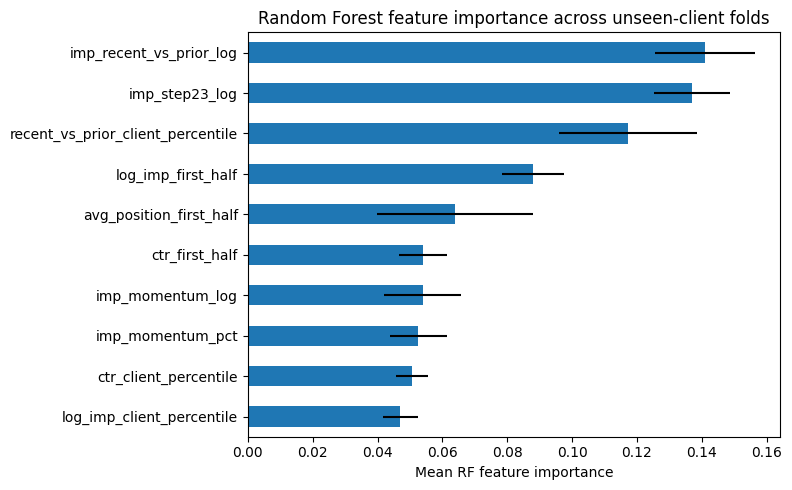

In [16]:
importance_summary = (
    rf_importance_df
    .groupby("feature", as_index=False)
    .agg(
        mean_importance=("importance", "mean"),
        std_across_folds=("importance", "std"),
    )
    .sort_values(
        "mean_importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("Top Random Forest features:")
display(
    importance_summary.head(10).style.format({
        "mean_importance": "{:.4f}",
        "std_across_folds": "{:.4f}",
    })
)

top_imp = (
    importance_summary
    .head(10)
    .sort_values("mean_importance")
)

ax = top_imp.plot.barh(
    x="feature",
    y="mean_importance",
    xerr="std_across_folds",
    legend=False,
    figsize=(8, 5),
)
ax.set_xlabel("Mean RF feature importance")
ax.set_ylabel("")
ax.set_title("Random Forest feature importance across unseen-client folds")
plt.tight_layout()
plt.show()


In [17]:
# Convert scores to within-fold percentiles before pooling errors.
oof_df["risk_percentile"] = (
    oof_df.groupby("fold")["rf_score"]
    .rank(method="average", pct=True)
)

safe_cols = [
    target_col,
    "risk_percentile",
    "log_imp_first_half",
    "imp_momentum_pct",
    "imp_acceleration",
    "imp_declining_steps",
    "ctr_change_5d_pp",
    "position_change_5d",
    "active_rate_change_5d",
]

false_positives = (
    oof_df[oof_df[target_col] == 0][safe_cols]
    .sort_values("risk_percentile", ascending=False)
    .head(3)
)

missed_declines = (
    oof_df[oof_df[target_col] == 1][safe_cols]
    .sort_values("risk_percentile", ascending=True)
    .head(3)
)

print("Three high-ranked false positives:")
display(false_positives)

print("Three low-ranked true declines:")
display(missed_declines)


Three high-ranked false positives:


,is_declining_proxy,risk_percentile,log_imp_first_half,imp_momentum_pct,imp_acceleration,imp_declining_steps,ctr_change_5d_pp,position_change_5d,active_rate_change_5d
25487,0,0.999905,7.805882,-82.500000,2.118877,1,-0.102881,20.231201,0.0
28510,0,0.999809,6.862758,-39.339539,-0.791359,2,0.000000,3.813219,0.0
1730,0,0.999722,6.375025,-50.766667,-1.717615,1,0.000000,8.279270,0.0


Three low-ranked true declines:


,is_declining_proxy,risk_percentile,log_imp_first_half,imp_momentum_pct,imp_acceleration,imp_declining_steps,ctr_change_5d_pp,position_change_5d,active_rate_change_5d
39213,1,0.000420,4.189655,111.842105,0.024837,0,0.0,-14.232143,0.0
16564,1,0.000636,4.219508,14.655172,-0.340927,0,0.0,-3.303704,0.0
34815,1,0.000780,3.850148,36.111111,0.462624,0,0.0,-7.295455,0.0


### Error interpretation

The two error types have different meanings.

**High-ranked false positives**  
The pre-outcome pattern looked risky enough for the model to rank the page highly, but the later decline threshold was not crossed. These cases are consistent with short-term volatility, recovery, or signals that look similar to true decline without persisting.

**Missed declines**  
The page later declined, but the first-half signals did not make it look sufficiently risky relative to other pages. These are the cases where the available pre-outcome window gave weak or misleading warning.

I treat feature importance as a **model-behavior sanity check**, not a causal explanation.


# 5) Self-check and robustness

The final conclusion should survive reasonable changes in validation design.

I run two checks:

### A. Splitter sensitivity
The primary splitter optimizes balance. To make sure that is not producing an artificially favorable result, I test the selected Random Forest on **3 genuinely different random balanced client partitions**.

These splits balance **client count only**. They do not optimize rows or outcome prevalence.

### B. April temporal holdout
After model selection is complete, I train the selected model on all outcome-evaluable March rows and evaluate it on **April 1–15 → April 16–30**.

This tests a different question:

> Does the March model transfer to a later time period?

It is a temporal robustness test, **not** a replacement for the unseen-client grouped validation. Some April clients may also exist in March.


In [24]:
# Random rows vs grouped clients — diagnostic only
# This does NOT replace the primary grouped validation.

from sklearn.model_selection import StratifiedKFold

random_cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

random_p100 = []
overlap_clients = []

for fold, (train_idx, test_idx) in enumerate(
    random_cv.split(
        model_df[FULL_FEATURES],
        model_df[target_col],
    ),
    start=1,
):
    train_part = model_df.iloc[train_idx]
    test_part = model_df.iloc[test_idx]

    rf = clone(random_forest_model)

    rf.fit(
        train_part[FULL_FEATURES],
        train_part[target_col],
    )

    scores = rf.predict_proba(
        test_part[FULL_FEATURES]
    )[:, 1]

    p100 = precision_at_k(
        test_part[target_col],
        scores,
    )

    random_p100.append(p100)

    overlap = (
        set(train_part["client_id"])
        & set(test_part["client_id"])
    )

    overlap_clients.append(len(overlap))

# Primary grouped RF results already calculated earlier
grouped_rf_p100 = primary_results.loc[
    primary_results["approach"]
    == "Random Forest — Full Signal",
    "p_at_100",
]

random_mean = float(np.mean(random_p100))
random_sd = float(np.std(random_p100, ddof=1))

grouped_mean = float(grouped_rf_p100.mean())
grouped_sd = float(grouped_rf_p100.std(ddof=1))

gap_pp = (random_mean - grouped_mean) * 100

comparison = pd.DataFrame([
    {
        "Validation": "Random row CV",
        "Mean P@100": random_mean,
        "SD": random_sd,
        "Client-disjoint": "No",
    },
    {
        "Validation": "Balanced client-grouped CV",
        "Mean P@100": grouped_mean,
        "SD": grouped_sd,
        "Client-disjoint": "Yes",
    },
])

print("Random rows vs unseen-client validation")
display(
    comparison.style.format({
        "Mean P@100": "{:.1%}",
        "SD": "{:.1%}",
    })
)

print(
    f"Random-row optimism gap: {gap_pp:+.1f} pp"
)

print(
    "Average clients appearing in BOTH train and validation "
    f"under random-row CV: {np.mean(overlap_clients):.1f}"
)

Random rows vs unseen-client validation


,Validation,Mean P@100,SD,Client-disjoint
0,Random row CV,90.6%,2.7%,No
1,Balanced client-grouped CV,76.8%,14.4%,Yes


Random-row optimism gap: +13.8 pp
Average clients appearing in BOTH train and validation under random-row CV: 28.8


### Random vs Grouped interpretation

Random-row CV is shown only as a diagnostic.

If its Precision@100 is higher than the balanced client-grouped result, this indicates that random row splitting gives an optimistic estimate because pages from the same clients can appear in both training and validation.

The **balanced client-grouped validation remains the primary model evaluation**.

In [18]:
def make_random_balanced_client_splits(
    frame,
    n_splits=N_SPLITS,
    random_state=0,
):
    """
    Client-disjoint stress-test splitter.

    Balances client count only.
    Does not use rows, positives, base rate, or model performance.
    """
    clients = frame["client_id"].drop_duplicates().to_numpy()
    rng = np.random.default_rng(random_state)
    clients = clients[rng.permutation(len(clients))]

    n_splits = min(int(n_splits), len(clients))
    fold_clients = np.array_split(clients, n_splits)

    splits = []

    for test_clients in fold_clients:
        test_set = set(test_clients)
        test_mask = frame["client_id"].isin(test_set).to_numpy()

        test_idx = np.flatnonzero(test_mask)
        train_idx = np.flatnonzero(~test_mask)

        assert set(frame.iloc[train_idx]["client_id"]).isdisjoint(
            set(frame.iloc[test_idx]["client_id"])
        )

        splits.append((train_idx, test_idx))

    counts = [
        frame.iloc[test_idx]["client_id"].nunique()
        for _, test_idx in splits
    ]

    assert max(counts) - min(counts) <= 1

    return splits


In [20]:
N_STRESS_REPEATS = 3
stress_rows = []

for repeat in range(1, N_STRESS_REPEATS + 1):
    splits = make_random_balanced_client_splits(
        model_df,
        n_splits=N_SPLITS,
        random_state=5000 + repeat,
    )

    for fold, (train_idx, test_idx) in enumerate(splits, start=1):
        train_part = model_df.iloc[train_idx].copy()
        test_part = model_df.iloc[test_idx].copy()

        week4_scores = score_week4_baseline(
            train_part,
            test_part,
        )

        rf = clone(random_forest_model)
        rf.fit(
            train_part[FULL_FEATURES],
            train_part[target_col],
        )
        rf_scores = rf.predict_proba(
            test_part[FULL_FEATURES]
        )[:, 1]

        stress_rows.append({
            "repeat": repeat,
            "fold": fold,
            "clients": test_part["client_id"].nunique(),
            "rows": len(test_part),
            "base_rate": float(test_part[target_col].mean()),
            "week4_p100": precision_at_k(
                test_part[target_col],
                week4_scores,
            ),
            "rf_p100": precision_at_k(
                test_part[target_col],
                rf_scores,
            ),
        })

stress_results = pd.DataFrame(stress_rows)
stress_results["delta_pp"] = (
    stress_results["rf_p100"]
    - stress_results["week4_p100"]
) * 100.0

stress_repeat = (
    stress_results
    .groupby("repeat", as_index=False)
    .agg(
        rf_mean_p100=("rf_p100", "mean"),
        week4_mean_p100=("week4_p100", "mean"),
        mean_delta_pp=("delta_pp", "mean"),
        rf_fold_sd=("rf_p100", "std"),
    )
)

print("Splitter stress-test repeat means:")
display(
    stress_repeat.style.format({
        "rf_mean_p100": "{:.1%}",
        "week4_mean_p100": "{:.1%}",
        "mean_delta_pp": "{:+.1f}",
        "rf_fold_sd": "{:.1%}",
    })
)

stress_rf_mean = float(stress_repeat["rf_mean_p100"].mean())
stress_rf_sd = float(stress_repeat["rf_mean_p100"].std())
stress_week4_mean = float(stress_repeat["week4_mean_p100"].mean())
stress_delta = float(stress_repeat["mean_delta_pp"].mean())
stress_wins = int((stress_repeat["mean_delta_pp"] > 0).sum())

print()
print("Stress-test RF mean:", f"{stress_rf_mean:.1%}")
print("Between-repeat SD:", f"{stress_rf_sd:.1%}")
print("Stress-test Week-4 mean:", f"{stress_week4_mean:.1%}")
print("Mean paired lift:", f"{stress_delta:+.1f} pp")
print(
    "RF repeat wins vs Week-4:",
    f"{stress_wins}/{N_STRESS_REPEATS}",
)


Splitter stress-test repeat means:


,repeat,rf_mean_p100,week4_mean_p100,mean_delta_pp,rf_fold_sd
0,1,76.2%,38.0%,+38.2,12.2%
1,2,76.0%,41.0%,+35.0,12.2%
2,3,77.4%,35.4%,+42.0,13.5%



Stress-test RF mean: 76.5%
Between-repeat SD: 0.8%
Stress-test Week-4 mean: 38.1%
Mean paired lift: +38.4 pp
RF repeat wins vs Week-4: 3/3


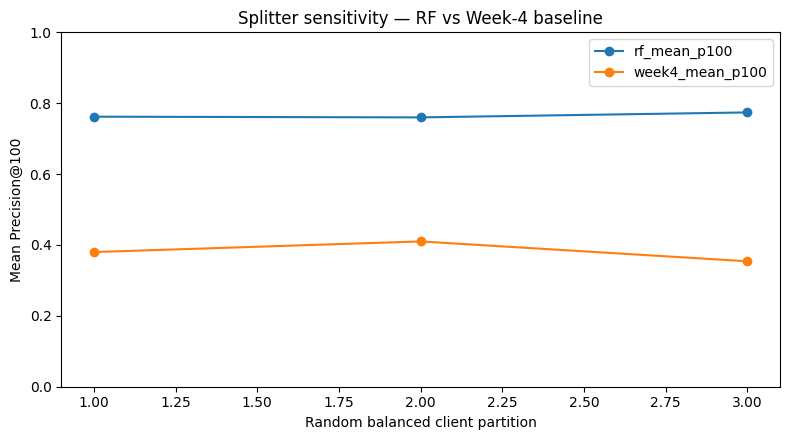

In [21]:
ax = stress_repeat.plot(
    x="repeat",
    y=["rf_mean_p100", "week4_mean_p100"],
    marker="o",
    figsize=(8, 4.5),
)
ax.set_xlabel("Random balanced client partition")
ax.set_ylabel("Mean Precision@100")
ax.set_title("Splitter sensitivity — RF vs Week-4 baseline")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


In [22]:
# Temporal holdout: train on March, test on the next month.
# April is available in the warehouse date range.
# This section does NOT choose the model; it only checks later-time robustness.

_, april_feature_population, april_df, april_info = (
    build_month_model_frame("2026-04")
)

print("April data:")
print(april_info)
print("April decline rate:", f"{april_df[target_col].mean():.1%}")

march_clients = set(model_df["client_id"])
april_clients = set(april_df["client_id"])

print(
    "April clients also present in March:",
    len(april_clients & march_clients),
)
print(
    "April clients not in March:",
    len(april_clients - march_clients),
)

# Freeze the selected RF using all March outcome-evaluable rows.
rf_temporal = clone(random_forest_model)
rf_temporal.fit(
    model_df[FULL_FEATURES],
    model_df[target_col],
)

april_rf_scores = rf_temporal.predict_proba(
    april_df[FULL_FEATURES]
)[:, 1]

# Freeze the Week-4 rule thresholds on March pre-outcome features,
# then apply those thresholds to April pre-outcome features.
april_week4_scores = score_week4_baseline(
    feature_population,
    april_df,
)

temporal_table = pd.DataFrame([
    evaluate_ranking(
        "Week-4 Rule Baseline",
        april_df[target_col],
        april_week4_scores,
    ),
    evaluate_ranking(
        "Random Forest — Full Signal",
        april_df[target_col],
        april_rf_scores,
    ),
])

print("APRIL TEMPORAL HOLDOUT — trained/frozen from March:")
display(
    temporal_table.style.format({
        "base_rate": "{:.1%}",
        "p_at_10": "{:.1%}",
        "p_at_100": "{:.1%}",
        "average_precision": "{:.3f}",
        "roc_auc": "{:.3f}",
    })
)

temporal_delta_pp = (
    temporal_table.loc[
        temporal_table["approach"] == "Random Forest — Full Signal",
        "p_at_100",
    ].iloc[0]
    - temporal_table.loc[
        temporal_table["approach"] == "Week-4 Rule Baseline",
        "p_at_100",
    ].iloc[0]
) * 100.0

print(
    "April RF minus Week-4 P@100:",
    f"{temporal_delta_pp:+.1f} pp",
)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

April data:
{'month': '2026-04', 'last_day': 30, 'future_days': 15, 'raw_rows': 362172, 'feature_rows': 89695, 'model_rows': 74572, 'clients': 41}
April decline rate: 45.1%
April clients also present in March: 34
April clients not in March: 7
APRIL TEMPORAL HOLDOUT — trained/frozen from March:


,approach,base_rate,p_at_10,p_at_100,average_precision,roc_auc
0,Week-4 Rule Baseline,45.1%,60.0%,47.0%,0.536,0.618
1,Random Forest — Full Signal,45.1%,90.0%,91.0%,0.551,0.609


April RF minus Week-4 P@100: +44.0 pp


### How to interpret the April result

April is intentionally **secondary evidence**.

- If March and April are similar, that supports short-horizon temporal robustness.
- If April is weaker, report the drop rather than hiding it.
- If April is stronger, do not claim the model “improved”; it may simply be an easier month.
- Because some clients can appear in both months, April does **not** replace the client-disjoint grouped test.

One future month is useful evidence, but it is not proof of long-term generalization.


In [23]:
# ---------------- FINAL WEEK-5 TABLE ----------------
# This is the table the assignment asks for:
# baseline and models, same split, same metric, plus base rate.

final_table = (
    primary_summary[
        primary_summary["approach"].isin([
            "Week-4 Rule Baseline",
            "Logistic Regression",
            "Random Forest — Full Signal",
        ])
    ][[
        "approach",
        "mean_base_rate",
        "mean_p100",
        "std_p100",
        "mean_ap",
        "mean_roc_auc",
    ]]
    .sort_values("mean_p100", ascending=False)
    .reset_index(drop=True)
)

print("=" * 86)
print("FINAL MODEL-vs-BASELINE TABLE — PRIMARY UNSEEN-CLIENT VALIDATION")
print("=" * 86)

display(
    final_table.style.format({
        "mean_base_rate": "{:.1%}",
        "mean_p100": "{:.1%}",
        "std_p100": "{:.1%}",
        "mean_ap": "{:.3f}",
        "mean_roc_auc": "{:.3f}",
    })
)

# Simplicity-aware final choice.
candidate_order = {
    "Week-4 Rule Baseline": 0,
    "Logistic Regression": 1,
    "Random Forest — Full Signal": 2,
}

top_p100 = float(final_table["mean_p100"].max())

near_ties = final_table[
    (
        top_p100 - final_table["mean_p100"]
    ) * 100.0 <= SIMPLICITY_TIE_PP
].copy()

near_ties["simplicity_rank"] = (
    near_ties["approach"]
    .map(candidate_order)
)

selected = (
    near_ties
    .sort_values(
        ["simplicity_rank", "mean_p100", "mean_ap"],
        ascending=[True, False, False],
    )
    .iloc[0]
)

selected_name = selected["approach"]
selected_p100 = float(selected["mean_p100"])

print("Selected approach:", selected_name)
print("Primary grouped P@100:", f"{selected_p100:.1%}")
print()
print(
    "Selection rule: choose the simpler approach if it is within "
    f"{SIMPLICITY_TIE_PP:.1f} percentage point of the best P@100."
)


FINAL MODEL-vs-BASELINE TABLE — PRIMARY UNSEEN-CLIENT VALIDATION


,approach,mean_base_rate,mean_p100,std_p100,mean_ap,mean_roc_auc
0,Random Forest — Full Signal,32.2%,76.8%,14.4%,0.527,0.705
1,Logistic Regression,32.2%,69.6%,22.1%,0.504,0.685
2,Week-4 Rule Baseline,32.2%,35.2%,6.4%,0.356,0.543


Selected approach: Random Forest — Full Signal
Primary grouped P@100: 76.8%

Selection rule: choose the simpler approach if it is within 1.0 percentage point of the best P@100.


## Final interpretation

The final claim should come from the executed tables above, not from a hard-coded number.

The defensible wording is:

> **The selected approach was evaluated against the exact Week-4 rule baseline on the same held-out client folds and the same Precision@100 metric. Client-disjoint validation is the primary evidence. Random-balanced repeated splits test sensitivity to the splitter, and April is a secondary temporal holdout.**

If the Random Forest remains the selected approach after **Run all**, the conclusion is that the learned nonlinear signal earned its extra complexity relative to the Week-4 rule.

If Logistic Regression lands within the one-percentage-point simplicity band, choose Logistic Regression instead.

If the Week-4 rule lands within that band, keep the rule rather than rewarding ML complexity.

### Limitations

- The target is a future-impression-decline proxy, not a causal refresh outcome.
- Only pages with complete feature and outcome coverage are evaluated.
- Client sizes are very unequal.
- Client heterogeneity remains part of the result.
- April adds one future month only; it does not prove long-term temporal generalization.
- Feature importance describes model behavior, not causality.


## Self-check

- [ ] Notebook runs top-to-bottom in a fresh Colab runtime.
- [ ] Week-4 baseline and learned models use the same held-out folds.
- [ ] Week-4 rule logic is unchanged; only its CTR medians are fitted on training/reference data to keep test clients untouched.
- [ ] No client ID, content ID, future field, or label is a model feature.
- [ ] Final table includes baseline, models, base rate, and the same primary metric.
- [ ] Error analysis shows concrete false positives and missed declines.
- [ ] Splitter stress test is reported honestly.
- [ ] April is described as temporal robustness, not as an independent unseen-client test.
- [ ] Claims use words such as observed, measured, directional, and decision-support.
- [ ] Save the executed file as `work/notebooks/w05_model.ipynb` and commit it.
